# imports

In [2]:
# !git clone https://github.com/moryacho/street-pattern-classifier.git

# !pip install huggingface_hub geopandas osmnx
# !pip install torch_geometric
# !pip install "folium>=0.12" matplotlib mapclassify

# !pip uninstall torch torchvision torchaudio -y
# !pip cache purge
# !pip install torch torchvision torchaudio

import torch

In [3]:
import geopandas as gpd
import numpy as np
import osmnx as ox
import pandas as pd
import time
from tqdm import tqdm
import os
import networkx as nx
import json

import matplotlib.pyplot as plt
from collections import Counter
from scipy import stats
import warnings

from shapely.geometry import LineString, Polygon, Point
import shapely
import pickle
import ast



# city names

In [ ]:
osm_city_names = [
    # East Asia
    "Beijing, China",
    "Chengdu, China",
    "Chongqing, China",
    "Guangzhou, China",
    "Hangzhou, China",
    "Shanghai, China",
    "Shenzhen, China",
    "Wuhan, China",
    "Nanjing, China",
    "Taipei, Taiwan",
    # "Tokyo, Japan", # multyoplygon: so buffer in the ocean
    "Osaka, Japan",
    "Seoul, South Korea",
    "Tianjin, China",
    
    # South Asia
    "Bangkok, Thailand",
    "Delhi, India",
    "Singapore, Singapore",
    "Kuala Lumpur, Malaysia",
    # "Mumbai, India",
    "Hyderabad, India",
    "Kathmandu, Nepal",
    
    # Oceania
    "Melbourne, Australia",
    "Sydney, Australia",
    "Auckland, New Zealand",
    "Brisbane, Australia",
    
    # Africa
    "Cairo, Egypt",
    "Casablanca, Morocco",
    "Lagos, Nigeria",
    "Nairobi, Kenya",
    # "Johannesburg, South Africa",
    
    # Europe
    "Amsterdam, Netherlands",
    "Brussels, Belgium",
    "London, United Kingdom",
    "Paris, France",
    "Berlin, Germany",
    "Munich, Germany",
    "Madrid, Spain",
    "Milan, Italy",
    "Moscow, Russia",
    "Stockholm, Sweden",
    "Bucharest, Romania",
    "Saint Petersburg, Russia",
    
    # North America
    "New York City, USA",  # Важно: именно "New York City", а не просто "New York"
    "Los Angeles, USA",
    "Detroit, USA",
    "Philadelphia, USA",
    "San Antonio, USA",
    "San Diego, USA",
    "Toronto, Canada",
    "Montreal, Canada",
    "Chicago, USA",
    "Houston, USA",
    "Phoenix, USA",
    
    # South America
    "Lima, Peru",
    "Bogota, Colombia",
    "Sao Paulo, Brazil",  # Можно также "São Paulo, Brazil"
    "Caracas, Venezuela",
    "Brasilia, Brazil",    # Можно также "Brasília, Brazil"
    "Asuncion, Paraguay"
]

# city polygons

representative point and buffer 20 km

In [ ]:
# city = "Tianjin, China" 
# # city = "244082077"
# gdf = ox.geocode_to_gdf(city) 
# # gdf = ox.
# p = shapely.Point(gdf.iloc[0].lon, gdf.iloc[0].lat)
# g = gpd.GeoDataFrame({"geometry" : [p, gdf.iloc[0].geometry]}, geometry="geometry", crs=4326)
# g.explore()

In [45]:
# city = "Saint Petersburg, Russia"

# gdf = ox.geocode_to_gdf(city) 
# p = shapely.Point(gdf.iloc[0].lon, gdf.iloc[0].lat)
# g = gpd.GeoDataFrame({"geometry" : [p, gdf.iloc[0].geometry]}, geometry="geometry", crs=4326)
# g.explore()

In [4]:
c = "Auckland, New Zealand"
gdf = ox.geocode_to_gdf(c) 
gdf.explore()

In [34]:
!pip install osmapi

In [7]:
# # Source - https://stackoverflow.com/a/55186769
# # Posted by marOne
# # Retrieved 2026-03-26, License - CC BY-SA 4.0

import osmapi as osm
api = osm.OsmApi() # this instantiate the OsmApi class,
# # it has many function, we will use NodeGet function.
# # For more detail about it check the doc
# # http://osmapi.metaodi.ch/#osmapi.OsmApi.OsmApi.NodeGet
# # node = api.RelationGet(421007)
node = api.relation_get(17000522)
# # node # will return a dict object

# p = shapely.Point(node["lon"], node["lat"])
# g = gpd.GeoDataFrame({"geometry" : [p]}, geometry="geometry", crs=4326)
# g.explore()


In [9]:
n = api.node_get(292806332)

In [11]:
p = shapely.Point(n["lon"], n["lat"])
g = gpd.GeoDataFrame({"geometry" : [p]}, geometry="geometry", crs=4326)
g.explore()

In [10]:
n

{'id': 292806332,
 'visible': True,
 'version': 50,
 'changeset': 179557732,
 'timestamp': datetime.datetime(2026, 3, 9, 3, 18, 16),
 'user': 'CoyKoi',
 'uid': 3757297,
 'lat': -36.852095,
 'lon': 174.7631803,
 'tag': {'admin_level': '4',
  'alt_name:mi': 'Ākarana',
  'alt_name:mk': 'Окланд',
  'loc_name': 'Akl',
  'name': 'Auckland',
  'name:af': 'Auckland',
  'name:am': 'ኦክለንድ፣ ኒው ዚላንድ',
  'name:an': 'Auckland',
  'name:ang': 'Aucland',
  'name:ar': 'أوكلاند',
  'name:ast': 'Auckland',
  'name:az': 'Oklənd',
  'name:be': 'Окленд',
  'name:bg': 'Окланд',
  'name:bh': 'ऑकलैंड',
  'name:bn': 'অকল্যান্ড',
  'name:br': 'Auckland',
  'name:ca': 'Auckland',
  'name:ce': 'Окленд',
  'name:ceb': 'Auckland',
  'name:ckb': 'ئۆکلاند',
  'name:cs': 'Auckland',
  'name:cu': 'Окландъ',
  'name:cy': 'Auckland',
  'name:da': 'Auckland',
  'name:de': 'Auckland',
  'name:el': 'Όκλαντ',
  'name:en': 'Auckland',
  'name:eo': 'Aŭklando',
  'name:es': 'Auckland',
  'name:et': 'Auckland',
  'name:etymology'

In [8]:
node

{'id': 17000522,
 'visible': True,
 'version': 9,
 'changeset': 176702573,
 'timestamp': datetime.datetime(2026, 1, 1, 13, 2, 18),
 'user': 'Yan Bakhmat',
 'uid': 12495047,
 'tag': {'admin_level': '6',
  'alt_name:mi': 'Ākarana',
  'alt_name:mk': 'Окланд',
  'boundary': 'administrative',
  'loc_name': 'Akl',
  'name': 'Auckland',
  'name:ar': 'أوكلاند',
  'name:en': 'Auckland',
  'name:ja': 'オークランド',
  'name:ko': '오클랜드',
  'name:mi': 'Tāmaki Makaurau',
  'name:mk': 'Окленд',
  'name:uk': 'Окленд',
  'population': '1642800',
  'ref': 'AUK',
  'source:population': 'Statistics NZ 2019',
  'type': 'boundary',
  'wikidata': 'Q726917',
  'wikipedia': 'en:Auckland Region'},
 'member': [{'type': 'way', 'ref': 319477352, 'role': 'outer'},
  {'type': 'way', 'ref': 402904576, 'role': 'outer'},
  {'type': 'way', 'ref': 843825373, 'role': 'outer'},
  {'type': 'way', 'ref': 319509360, 'role': 'outer'},
  {'type': 'way', 'ref': 1326240988, 'role': 'outer'},
  {'type': 'way', 'ref': 319509286, 'role':

In [4]:
BUFFER = 20000
data = []

for city in tqdm(osm_city_names):
    gdf = ox.geocode_to_gdf(city)
    if gdf.crs != 4326:
        print(f"Исходная CRS: {gdf.crs}")
    gdf_projected = gdf.to_crs(gdf.estimate_utm_crs())
    # center_point_projected = gdf_projected.centroid.iloc[0]
    center_point_projected = gdf_projected.representative_point().iloc[0]
    
    point_gdf_utm = gpd.GeoDataFrame(geometry=[center_point_projected], crs=gdf_projected.crs)
    buffer_utm = point_gdf_utm.buffer(BUFFER)
    buffer_geo = buffer_utm.to_crs(gdf.crs)    
    center_point_geo = gpd.GeoDataFrame(geometry=[center_point_projected], crs=gdf_projected.crs).to_crs(gdf.crs).geometry.iloc[0]
    
    data.append({
        "city_name": city,
        "centroid": center_point_geo,
        "geometry": buffer_geo.geometry.iloc[0]
    })

100%|██████████| 55/55 [00:06<00:00,  8.45it/s]


In [5]:
gdf_centroids_polygons = gpd.GeoDataFrame(data, crs='EPSG:4326', geometry='geometry')

In [6]:
gdf_centroids_polygons.explore()

# drive graph data

In [54]:
# Source - https://stackoverflow.com/a/77965352
# Posted by Nick ODell
# Retrieved 2026-03-19, License - CC BY-SA 4.0

import osmnx as ox

# Must be an overpass instance which supports attic
ox.settings.overpass_endpoint = "https://overpass-api.de/api"

def query_year(coordinate, year):
    date = f'{year}-01-01T00:00:00Z'
    # Request attic data
    ox.settings.overpass_settings = '[out:json][timeout:{timeout}][date:"' + date + '"]{maxsize}'
    graph = ox.graph.graph_from_polygon(coordinate)
    # Restore old settings
    ox.settings.overpass_settings = '[out:json][timeout:{timeout}]{maxsize}'
    return graph


In [ ]:
# gdf_centroids_polygons['graph_2024'] = None
# gdf_centroids_polygons['graph_2020'] = None


# for i in tqdm(range(len(gdf_centroids_polygons))):
#     row = gdf_centroids_polygons.iloc[i]
#     polygon = row['geometry']
#     if gdf_centroids_polygons.at[row.name, 'graph_2024']:
#         print(f"place {row.city_name} already downloaded")
#         continue
#     try:
#         drive_graph_2024 = query_year(polygon, 2024)
#         drive_graph_2020 = query_year(polygon, 2020)
        
#         gdf_centroids_polygons.at[row.name, 'graph_2024'] = drive_graph_2024
#         gdf_centroids_polygons.at[row.name, 'graph_2020'] = drive_graph_2020
#     except Exception  as e:
#         print(f"place: {row.city_name} error: {e}")

# #     if i % 10 == 0:
# #         gdf_centroids_polygons.to_pickle(f"graphs_through_years//gdf_{i // 10}.pkl")

# # gdf_centroids_polygons.to_pickle(f"graphs_through_years//gdf_final.pkl")


In [10]:
gdf_centroids_polygons['graph_2024'] = None
gdf_centroids_polygons['graph_2020'] = None

import os
os.makedirs("graphs_by_city", exist_ok=True)

for i in tqdm(range(len(gdf_centroids_polygons))):
    row = gdf_centroids_polygons.iloc[i]
    polygon = row['geometry']
    city_name = row['city_name']
    
    city_filename = f"graphs_by_city/{city_name.replace('/', '_')}.pkl"
    
    if os.path.exists(city_filename):
        print(f"place {city_name} already downloaded")
        # Загружаем из файла, если нужно
        # saved_data = pd.read_pickle(city_filename)
        # gdf_centroids_polygons.at[row.name, 'graph_2024'] = saved_data['graph_2024']
        # gdf_centroids_polygons.at[row.name, 'graph_2020'] = saved_data['graph_2020']
        continue
    
    try:
        drive_graph_2024 = query_year(polygon, 2024)
        drive_graph_2020 = query_year(polygon, 2020)
        
        # gdf_centroids_polygons.at[row.name, 'graph_2024'] = drive_graph_2024
        # gdf_centroids_polygons.at[row.name, 'graph_2020'] = drive_graph_2020
        
        # Сохраняем данные города в отдельный файл
        city_data = {
            'city_name': city_name,
            'centroid': row['centroid'],
            'geometry': polygon,
            'graph_2024': drive_graph_2024,
            'graph_2020': drive_graph_2020
        }
        pd.to_pickle(city_data, city_filename)
        print(f"Saved {city_name}")
        
    except Exception as e:
        print(f"place: {city_name} error: {e}")

# Сохраняем итоговый DataFrame (опционально)
# gdf_centroids_polygons.to_pickle("graphs_by_city/final_dataframe.pkl")

  2%|▏         | 1/55 [01:38<1:28:46, 98.63s/it]

Saved Beijing, China


  4%|▎         | 2/55 [02:45<1:10:31, 79.83s/it]

Saved Chengdu, China


  5%|▌         | 3/55 [05:02<1:32:02, 106.20s/it]

...

Saved Caracas, Venezuela


 98%|█████████▊| 54/55 [4:46:31<03:12, 192.69s/it]

Saved Brasilia, Brazil


100%|██████████| 55/55 [4:48:08<00:00, 314.34s/it]

Saved Asuncion, Paraguay


# read 

In [ ]:
# dict_ams = pd.read_pickle("graphs_by_city//Chongqing, China.pkl")

In [4]:
df = pd.read_pickle("graphs_by_city//Auckland, New Zealand.pkl")

In [5]:
for i, j in df.items():
    df[i] = [df[i]]

In [6]:
df

{'city_name': ['Chongqing, China'],
 'centroid': [<POINT (107.885 30.205)>],
 'geometry': [<POLYGON ((108.092 30.2, 108.091 30.182, 108.087 30.165, 108.082 30.148, 108...>],
 'graph_2024': [<networkx.classes.multidigraph.MultiDiGraph at 0x1dd65633dd0>],
 'graph_2020': [<networkx.classes.multidigraph.MultiDiGraph at 0x1dd65c7e090>]}

In [6]:
gh = pd.DataFrame.from_dict(df)

In [8]:
type(df)

dict

In [9]:
gh

,city_name,centroid,geometry,graph_2024,graph_2020
0,"Chongqing, China",POINT (107.88489472552504 30.204540206457214),POLYGON ((108.09239976966401 30.19980633696231...,"(841520930, 841521019, 841521304, 841521608, 8...","(841520930, 841521019, 841521304, 841521671, 8..."


In [7]:
gdf_ams = gpd.GeoDataFrame(gh, geometry="geometry")

In [8]:
 gdf_ams = gdf_ams.set_crs(4326)

In [ ]:
# gdf_ams.explore()

<Axes: >

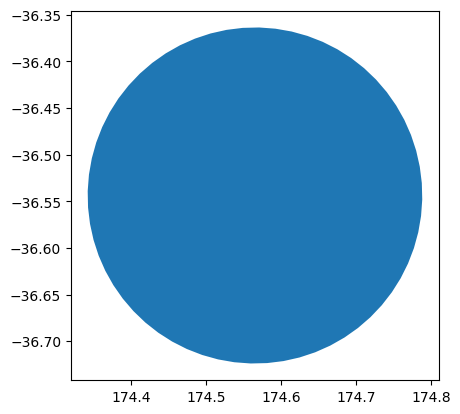

In [99]:
gdf_ams.plot()

In [22]:
gdf_ams.iloc[0].graph_2020

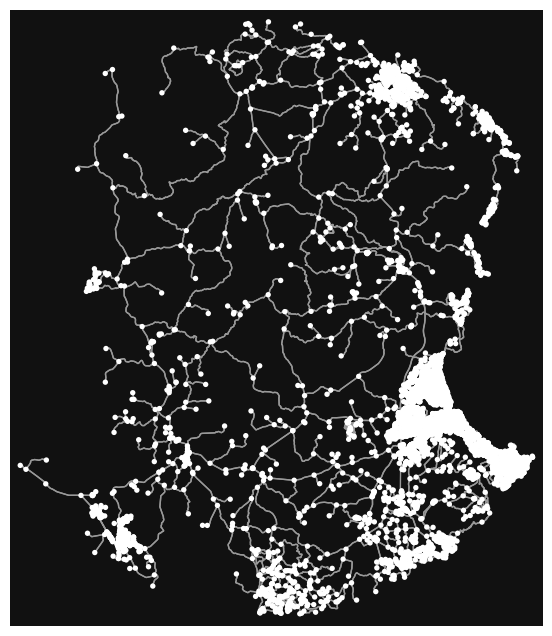

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [100]:
ox.plot_graph(gdf_ams.iloc[0].graph_2020)

In [67]:
import random
import numpy as np
import networkx as nx
import osmnx as ox
import geopandas as gpd
from tqdm import tqdm
from rtree import index
from shapely.geometry import LineString, Polygon, Point
from shapely import box
from itertools import combinations
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import shapely

def split_graph_by_grid(G, big_polygon, grid_step=1000):

    nodes, edges = ox.graph_to_gdfs(G)
    bounds = nodes.total_bounds
    bounds = big_polygon.bounds

    minx, miny, maxx, maxy = bounds

    x_coords = np.arange(minx, maxx, grid_step)
    y_coords = np.arange(miny, maxy, grid_step)

    if len(x_coords) == 0 or x_coords[-1] < maxx:
        x_coords = np.append(x_coords, maxx)
    if len(y_coords) == 0 or y_coords[-1] < maxy:
        y_coords = np.append(y_coords, maxy)

    subgraphs = {}

    node_cell_idx = index.Index()
    node_cell_bounds = {}

    for i in range(len(x_coords) - 1):
        for j in range(len(y_coords) - 1):
            cell_polygon = Polygon([
                (x_coords[i], y_coords[j]),
                (x_coords[i+1], y_coords[j]),
                (x_coords[i+1], y_coords[j+1]),
                (x_coords[i], y_coords[j+1])
            ])

            subgraph = nx.MultiDiGraph()
            subgraph.graph['crs'] = G.graph['crs']

            subgraphs[(i, j)] = {
                'graph': subgraph,
                'polygon': cell_polygon
            }

    for i, (key, cell_data) in enumerate(subgraphs.items()):
        bounds = cell_data['polygon'].bounds
        node_cell_idx.insert(i, bounds)
        node_cell_bounds[i] = (key, cell_data)

    node_to_cell = {}

    for node, data in tqdm(G.nodes(data=True), desc="Assigning nodes to cells"):
        point = Point(data['x'], data['y'])

        potential_cells = list(node_cell_idx.intersection((data['x'], data['y'], data['x'], data['y'])))

        assigned_to_cell = False

        for cell_idx in potential_cells:
            key, cell_data = node_cell_bounds[cell_idx]
            if cell_data['polygon'].contains(point):
                cell_data['graph'].add_node(node, **data)
                node_to_cell[node] = key
                assigned_to_cell = True
                break

        if not assigned_to_cell:
            for cell_idx in potential_cells:
                key, cell_data = node_cell_bounds[cell_idx]
                if cell_data['polygon'].intersects(point):
                    cell_data['graph'].add_node(node, **data)
                    node_to_cell[node] = key
                    break

    edge_cell_idx = index.Index()
    edge_cell_data_by_idx = {}

    for i, (key, cell_data) in enumerate(subgraphs.items()):
        bounds = cell_data['polygon'].bounds
        edge_cell_idx.insert(i, bounds)
        edge_cell_data_by_idx[i] = (key, cell_data)

    edges_with_geometry = []
    for u, v, key, data in G.edges(keys=True, data=True):
        if 'geometry' in data:
            line = data['geometry']
        else:
            u_x, u_y = G.nodes[u]['x'], G.nodes[u]['y']
            v_x, v_y = G.nodes[v]['x'], G.nodes[v]['y']
            line = LineString([(u_x, u_y), (v_x, v_y)])
        edges_with_geometry.append((u, v, key, data, line))

    for u, v, key, data, line in tqdm(edges_with_geometry, desc="Assigning edges to cells"):
        u_cell = node_to_cell.get(u)
        v_cell = node_to_cell.get(v)

        line_bounds = line.bounds
        potential_cell_indices = list(edge_cell_idx.intersection(line_bounds))

        for cell_index in potential_cell_indices:
            cell_key, cell_data = edge_cell_data_by_idx[cell_index]
            cell_polygon = cell_data['polygon']

            cell_bounds = cell_polygon.bounds
            if (line_bounds[0] > cell_bounds[2] or line_bounds[2] < cell_bounds[0] or
                line_bounds[1] > cell_bounds[3] or line_bounds[3] < cell_bounds[1]):
                continue

            if not line.intersects(cell_polygon):
                continue

            subgraph = cell_data['graph']
            intersection = line.intersection(cell_polygon)

            if intersection.is_empty:
                continue

            if intersection.geom_type == 'LineString':
                segments = [intersection]
            elif intersection.geom_type == 'MultiLineString':
                segments = list(intersection.geoms)
            else:
                continue

            for segment in segments:
                start_coord = segment.coords[0]
                end_coord = segment.coords[-1]

                start_node_exists = u in subgraph.nodes() if cell_key == u_cell else False
                end_node_exists = v in subgraph.nodes() if cell_key == v_cell else False

                if start_node_exists and end_node_exists:
                    start_node_id = u
                    end_node_id = v
                elif start_node_exists:
                    start_node_id = u
                    end_node_id = f"end_{u}_{v}_{key}_{hash(segment.wkt) % 10000:04d}"
                    subgraph.add_node(end_node_id, x=end_coord[0], y=end_coord[1])
                elif end_node_exists:
                    start_node_id = f"start_{u}_{v}_{key}_{hash(segment.wkt) % 10000:04d}"
                    end_node_id = v
                    subgraph.add_node(start_node_id, x=start_coord[0], y=start_coord[1])
                else:
                    start_node_id = f"start_{u}_{v}_{key}_{hash(segment.wkt) % 10000:04d}"
                    end_node_id = f"end_{u}_{v}_{key}_{hash(segment.wkt) % 10000:04d}"
                    subgraph.add_node(start_node_id, x=start_coord[0], y=start_coord[1])
                    subgraph.add_node(end_node_id, x=end_coord[0], y=end_coord[1])

                edge_data = data.copy()
                edge_data['geometry'] = segment
                edge_data['original_nodes'] = (u, v)
                edge_data['segment_id'] = f"{u}_{v}_{key}_{hash(segment.wkt) % 10000:04d}"
                edge_data['original_edge_key'] = key

                subgraph.add_edge(start_node_id, end_node_id, **edge_data)

    result = {}
    for key, cell_data in subgraphs.items():
        if len(cell_data['graph'].nodes) > 0:
            result[key] = {
                'graph': cell_data['graph'],
                'polygon': cell_data['polygon']
            }

    return result

In [10]:
gdf_ams_copy = gdf_ams.copy()
gdf_ams_copy = gdf_ams_copy.to_crs(gdf_ams_copy.estimate_utm_crs())

In [103]:
gdf_ams_copy.crs

<Projected CRS: EPSG:32760>
Name: WGS 84 / UTM zone 60S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 174°E and 180°E, southern hemisphere between 80°S and equator, onshore and offshore. New Zealand.
- bounds: (174.0, -80.0, 180.0, 0.0)
Coordinate Operation:
- name: UTM zone 60S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [11]:
subgraphs_2020 = split_graph_by_grid(ox.project_graph(gdf_ams_copy.iloc[0].graph_2020), gdf_ams_copy.iloc[0].geometry)

Assigning edges to cells: 100%|██████████| 21099/21099 [00:05<00:00, 3980.51it/s]


In [12]:
subgraphs_2024 = split_graph_by_grid(ox.project_graph(gdf_ams_copy.iloc[0].graph_2024), gdf_ams_copy.iloc[0].geometry)

Assigning edges to cells: 100%|██████████| 46733/46733 [00:10<00:00, 4506.14it/s]


In [13]:
len(subgraphs_2020)

778

In [107]:
len(subgraphs_2024)


851

In [14]:
import sys
sys.path.insert(0, './street-pattern-classifier')
from block_dataset import BlockDataset

dataset_2020 = BlockDataset(subgraphs_2020)

d:\выбирай итмо и не  выбирай вообще\urban\corr_transport_street_pattern\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Computing features for all subgraphs...


Processing subgraphs...: 100%|██████████| 778/778 [06:55<00:00,  1.87it/s]

Normalization...
Number of nodes: 6373
Number of features: 8
Подготовлено 778 блоков с корректными признаками


In [15]:
dataset_2024 = BlockDataset(subgraphs_2024)

Computing features for all subgraphs...


Processing subgraphs...: 100%|██████████| 851/851 [24:45<00:00,  1.75s/it]   

Normalization...
Number of nodes: 10914
Number of features: 8
Подготовлено 851 блоков с корректными признаками


In [16]:
model_path = "models//best_model.pth"

In [17]:
from classification import classify_blocks
predictions_blocks_2020, probabilities_blocks_2020 = classify_blocks(
    dataset_2020,
    model_path=model_path,
    device='cpu'
)

Модель загружена


Processing batches: 100%|██████████| 25/25 [00:01<00:00, 12.81it/s]


In [18]:
from classification import classify_blocks
predictions_blocks_2024, probabilities_blocks_2024 = classify_blocks(
    dataset_2024,
    model_path=model_path,
    device='cpu'
)

Модель загружена


Processing batches:   0%|          | 0/27 [00:00<?, ?it/s]

Processing batches: 100%|██████████| 27/27 [00:02<00:00,  9.14it/s]


In [19]:
class_names=["Loops & Lollipops", "Irregular Grid", "Regular Grid", 
                 "Warped Parallel", "Sparse", "Broken Grid"]

In [66]:
data = {"id": [],
        "geometry": [],
        "graph_2020": [],
        "graph_2024": [],
        "pred_id_2020": [],
        "pred_id_2024": [],
        "pred_class_2020": [],
        "pred_class_2024": [],
        "prob_Loops_Lollipops_2020": [],
        "prob_Irregular_Grid_2020" : [],
        "prob_Regular_Grid_2020" : [],
        "prob_Warped_Parallel_2020" : [],
        "prob_Sparse_2020" : [],
        "prob_Broken_Grid_2020" : [],
        
        "prob_Loops_Lollipops_2024": [],
        "prob_Irregular_Grid_2024" : [],
        "prob_Regular_Grid_2024" : [],
        "prob_Warped_Parallel_2024" : [],
        "prob_Sparse_2024" : [],
        "prob_Broken_Grid_2024" : [],

        }


class_names=["Loops Lollipops", "Irregular Grid", "Regular Grid", 
                 "Warped Parallel", "Sparse", "Broken Grid"]

idx = 0
for i, j in subgraphs_2024:
    data["id"].append(idx)
    data["geometry"].append(subgraphs_2024[i, j]["polygon"])
    
    try:
        # subgraphs_2020[i, j]["graph"]:
        # pred_2020 = predictions_blocks_2020[i, j]
        data["graph_2020"].append(subgraphs_2020[i, j]["graph"])
        pred_2020 = predictions_blocks_2020[i, j]

        data["pred_id_2020"].append(pred_2020)
        data["pred_class_2020"].append(class_names[pred_2020])
        for p in range(len(probabilities_blocks_2020[i, j])):
            data[f"prob_{class_names[p].replace(' ', '_')}_2020"].append(probabilities_blocks_2020[i, j][p])
    except Exception as e:
        data["graph_2020"].append(None)
        data["pred_id_2020"].append(None)
        data["pred_class_2020"].append(None)
        for p in range(len(class_names)):
            data[f"prob_{class_names[p].replace(' ', '_')}_2020"].append(None)

    data["graph_2024"].append(subgraphs_2024[i, j]["graph"])
    
    # pred_2020 = predictions_blocks_2020[i, j]
    pred_2024 = predictions_blocks_2024[i, j]
    # data["pred_id_2020"].append(pred_2020)
    data["pred_id_2024"].append(pred_2024)
    # data["pred_class_2020"].append(class_names[pred_2020])
    data["pred_class_2024"].append(class_names[pred_2024])

    # for p in range(len(probabilities_blocks_2020[i, j])):
    #     data[f"prob_{p}_2020"].append(probabilities_blocks_2020[i, j][p])

    for p in range(len(probabilities_blocks_2024[i, j])):
        # data[f"prob_{p}_2024"].append(probabilities_blocks_2024[i, j][p])
        data[f"prob_{class_names[p].replace(' ', '_')}_2024"].append(probabilities_blocks_2024[i, j][p])

    idx += 1
    

NameError: name 'subgraphs_2024' is not defined

In [44]:
predicted_gdf = gpd.GeoDataFrame(data, geometry="geometry", crs=32760)

In [45]:
predicted_gdf["class_changed"] = predicted_gdf["pred_id_2020"] != predicted_gdf["pred_id_2024"]

In [46]:
predicted_gdf.explore(column="class_changed")

In [47]:
predicted_gdf["classes_before_after"] = predicted_gdf["pred_class_2020"].astype(str) + " -> " + predicted_gdf["pred_class_2024"].astype(str)

In [48]:
predicted_gdf_only_changed = predicted_gdf.copy()
predicted_gdf_only_changed = predicted_gdf_only_changed[predicted_gdf_only_changed["class_changed"] == True]

In [49]:
len(predicted_gdf_only_changed)

406

In [50]:
predicted_gdf_only_changed["classes_before_after"] = predicted_gdf_only_changed["pred_class_2020"].astype(str) + " -> " + predicted_gdf_only_changed["pred_class_2024"].astype(str)

In [51]:
set(predicted_gdf_only_changed["classes_before_after"].to_list())

{'Broken Grid -> Irregular Grid',
 'Broken Grid -> Loops Lollipops',
 'Broken Grid -> Regular Grid',
 'Broken Grid -> Sparse',
 'Broken Grid -> Warped Parallel',
 'Irregular Grid -> Broken Grid',
 'Irregular Grid -> Loops Lollipops',
 'Irregular Grid -> Regular Grid',
 'Irregular Grid -> Sparse',
 'Irregular Grid -> Warped Parallel',
 'Loops Lollipops -> Broken Grid',
 'Loops Lollipops -> Irregular Grid',
 'Loops Lollipops -> Regular Grid',
 'Loops Lollipops -> Sparse',
 'Loops Lollipops -> Warped Parallel',
 'None -> Broken Grid',
 'None -> Irregular Grid',
 'None -> Loops Lollipops',
 'None -> Regular Grid',
 'None -> Sparse',
 'None -> Warped Parallel',
 'Regular Grid -> Broken Grid',
 'Regular Grid -> Irregular Grid',
 'Regular Grid -> Loops Lollipops',
 'Regular Grid -> Sparse',
 'Regular Grid -> Warped Parallel',
 'Sparse -> Broken Grid',
 'Sparse -> Irregular Grid',
 'Sparse -> Loops Lollipops',
 'Sparse -> Regular Grid',
 'Sparse -> Warped Parallel',
 'Warped Parallel -> Broken

In [52]:
predicted_gdf_only_changed.head()

,id,geometry,graph_2020,graph_2024,pred_id_2020,pred_id_2024,pred_class_2020,pred_class_2024,prob_Loops_Lollipops_2020,prob_Irregular_Grid_2020,...,prob_Sparse_2020,prob_Broken_Grid_2020,prob_Loops_Lollipops_2024,prob_Irregular_Grid_2024,prob_Regular_Grid_2024,prob_Warped_Parallel_2024,prob_Sparse_2024,prob_Broken_Grid_2024,class_changed,classes_before_after
4,4,"POLYGON ((267045.654 5939986.198, 268045.654 5...","(start_279051937_4792958668_0_5891, end_279051...","(start_279051937_4792958668_0_7403, end_279051...",5.0,4,Broken Grid,Sparse,0.058565,0.141589,...,0.264795,0.294049,0.038648,0.110555,0.118221,0.105777,0.407349,0.219450,True,Broken Grid -> Sparse
5,5,"POLYGON ((267045.654 5940986.198, 268045.654 5...","(279051937, start_279051895_279051937_0_1577, ...","(279051937, start_279051895_279051937_0_5664, ...",3.0,4,Warped Parallel,Sparse,0.054859,0.153957,...,0.227809,0.185448,0.049419,0.112951,0.093607,0.242611,0.376285,0.125127,True,Warped Parallel -> Sparse
8,8,"POLYGON ((268045.654 5957986.198, 269045.654 5...",None,"(8332306201, 8332332028, 8332349141, 833234919...",NaN,1,None,Irregular Grid,NaN,NaN,...,NaN,NaN,0.187593,0.501500,0.077544,0.117594,0.066062,0.049706,True,None -> Irregular Grid
9,9,"POLYGON ((268045.654 5958986.198, 269045.654 5...",None,"(8332356970, 8332397146, 8332338547, 833237114...",NaN,1,None,Irregular Grid,NaN,NaN,...,NaN,NaN,0.319822,0.535759,0.019149,0.066322,0.038318,0.020630,True,None -> Irregular Grid
10,10,"POLYGON ((268045.654 5959986.198, 269045.654 5...",None,"(8332382144, 8332382207, 8332382193, start_833...",NaN,0,None,Loops Lollipops,NaN,NaN,...,NaN,NaN,0.400394,0.220295,0.154170,0.068196,0.065788,0.091158,True,None -> Loops Lollipops


In [53]:
import folium
m = predicted_gdf.explore(column="pred_class_2020", name='20')
m = predicted_gdf.explore(column="pred_class_2024", m=m, name='24')
folium.LayerControl().add_to(m)
m

In [54]:
predicted_gdf.head()

,id,geometry,graph_2020,graph_2024,pred_id_2020,pred_id_2024,pred_class_2020,pred_class_2024,prob_Loops_Lollipops_2020,prob_Irregular_Grid_2020,...,prob_Sparse_2020,prob_Broken_Grid_2020,prob_Loops_Lollipops_2024,prob_Irregular_Grid_2024,prob_Regular_Grid_2024,prob_Warped_Parallel_2024,prob_Sparse_2024,prob_Broken_Grid_2024,class_changed,classes_before_after
0,0,"POLYGON ((265045.654 5941986.198, 266045.654 5...","(279051895, 4792958717, end_279051895_48151405...","(279051895, 4792958717, end_279051895_48151405...",5.0,5,Broken Grid,Broken Grid,0.135898,0.166009,...,0.110376,0.293336,0.157302,0.168880,0.174652,0.083092,0.113524,0.302550,False,Broken Grid -> Broken Grid
1,1,"POLYGON ((266045.654 5940986.198, 267045.654 5...","(start_279051895_279051937_0_2045, end_2790518...","(start_279051895_279051937_0_6617, end_2790518...",4.0,4,Sparse,Sparse,0.049035,0.139451,...,0.268839,0.258483,0.043876,0.116407,0.108165,0.151759,0.401799,0.177995,False,Sparse -> Sparse
2,2,"POLYGON ((266045.654 5941986.198, 267045.654 5...","(start_279051895_4815140520_0_7608, end_279051...","(start_279051895_4815140520_0_7608, end_279051...",5.0,5,Broken Grid,Broken Grid,0.031847,0.092411,...,0.162568,0.400053,0.018836,0.105744,0.166004,0.196653,0.164495,0.348268,False,Broken Grid -> Broken Grid
3,3,"POLYGON ((266045.654 5942986.198, 267045.654 5...","(start_279051895_4815140520_0_2671, end_279051...","(start_279051895_4815140520_0_2671, end_279051...",5.0,5,Broken Grid,Broken Grid,0.082671,0.143205,...,0.168688,0.305301,0.060081,0.103567,0.200789,0.107533,0.208703,0.319327,False,Broken Grid -> Broken Grid
4,4,"POLYGON ((267045.654 5939986.198, 268045.654 5...","(start_279051937_4792958668_0_5891, end_279051...","(start_279051937_4792958668_0_7403, end_279051...",5.0,4,Broken Grid,Sparse,0.058565,0.141589,...,0.264795,0.294049,0.038648,0.110555,0.118221,0.105777,0.407349,0.219450,True,Broken Grid -> Sparse


AttributeError: 'Series' object has no attribute 'graph'

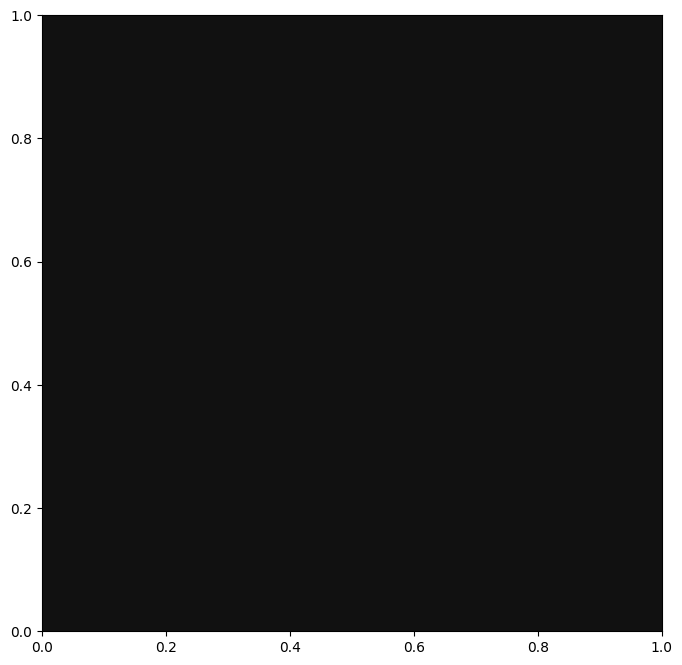

In [55]:
ox.plot_graph(gdf_ams_copy.iloc[0])

In [56]:
nodes_2020, edges_2020 = ox.graph_to_gdfs(gdf_ams_copy.iloc[0].graph_2020)
nodes_2024, edges_2024 = ox.graph_to_gdfs(gdf_ams_copy.iloc[0].graph_2024)

In [57]:
gdf_diff = edges_2024.geometry.difference(edges_2020)

C:\Users\yanaz\AppData\Local\Temp\ipykernel_18052\2664611022.py:1: UserWarning: The indices of the left and right GeoSeries' are not equal, and therefore they will be aligned (reordering and/or introducing missing values) before executing the operation. If this alignment is the desired behaviour, you can silence this warning by passing 'align=True'. If you don't want alignment and protect yourself of accidentally aligning, you can pass 'align=False'.
  gdf_diff = edges_2024.geometry.difference(edges_2020)


In [58]:
gdf_diff = gdf_diff.dropna()

In [59]:
gdf_diff

u           v           key
716253      884382151   0      MULTILINESTRING ((174.66359 -36.59064, 174.663...
716265      2309467106  0      LINESTRING (174.6728 -36.58938, 174.67217 -36....
            6948409278  0      MULTILINESTRING ((174.6728 -36.58938, 174.6728...
716505      735144508   0      LINESTRING (174.67601 -36.52318, 174.67596 -36...
716507      735144508   0      LINESTRING (174.67558 -36.52212, 174.67577 -36...
                                                     ...                        
7069127997  7069127994  0                                       LINESTRING EMPTY
7069128004  6964938638  0                                       LINESTRING EMPTY
7069128007  964666727   0                                       LINESTRING EMPTY
            2782609432  0                                       LINESTRING EMPTY
            6965206413  0                                       LINESTRING EMPTY
Length: 16025, dtype: geometry

In [60]:
import folium
m = edges_2020.geometry.explore(name='20')
m = gdf_diff.explore(m=m, name='24', color="red")
folium.LayerControl().add_to(m)
m.save("auckland_grapf_diff.html")

In [61]:
gdf_diff.explore()

layers:

class 2020

class 2024

class changed (true false)

edges 2020

edge diff

In [62]:
import folium
m = edges_2020.geometry.explore(name='20')
m = gdf_diff.explore(m=m, name='24', color="red")
m = predicted_gdf.explore(column="pred_class_2020", name='20')
m = predicted_gdf.explore(column="pred_class_2024", m=m, name='24')
m = predicted_gdf.explore(column="class_changed", m=m, name='24')
folium.LayerControl().add_to(m)
m.save("auckland_graphs.html")

In [63]:
import folium
import geopandas as gpd

# Создаем базовую карту
m = folium.Map(location=[-36.8485, 174.7633], zoom_start=12)  # Координаты Окленда

# Добавляем predicted_gdf с class_changed
m = predicted_gdf.explore(
    m=m,
    column="class_changed",
    name='Class Changed',
    # cmap='RdYlBu',
    legend=True
)


# Добавляем predicted_gdf с pred_class_2020
m = predicted_gdf.explore(
    m=m,
    column="pred_class_2020",
    name='Predicted 2020',
    # cmap='viridis',
    legend=True
)

# Добавляем predicted_gdf с pred_class_2024
m = predicted_gdf.explore(
    m=m,
    column="pred_class_2024",
    name='Predicted 2024',
    # cmap='plasma',
    legend=True
)


# Добавляем слои по очереди, сохраняя ссылку на карту
m = edges_2020.geometry.explore(m=m, name='2020 Roads', color='blue')

# Добавляем gdf_diff
m = gdf_diff.explore(m=m, name='2024 Roads', color='red')

# Добавляем контроллер слоев
folium.LayerControl().add_to(m)

# Сохраняем карту
m.save("auckland_graphs.html")

# print("Карта сохранена как auckland_graphs.html")

# Taijin

In [ ]:
# Source - https://stackoverflow.com/a/55186769
# Posted by marOne
# Retrieved 2026-03-26, License - CC BY-SA 4.0

import osmapi as osm
api = osm.OsmApi() # this instantiate the OsmApi class,
# it has many function, we will use NodeGet function.
# http://osmapi.metaodi.ch/#osmapi.OsmApi.OsmApi.NodeGet
node = api.NodeGet(244082077)
# node = api.NodeGet(244082077)
# node # will return a dict object

p = shapely.Point(node["lon"], node["lat"])
g = gpd.GeoDataFrame({"geometry" : [p]}, geometry="geometry", crs=4326)
g.explore()


C:\Users\yanaz\AppData\Local\Temp\ipykernel_19980\4030737058.py:10: DeprecationWarning: NodeGet() is deprecated, use node_get() instead
  node = api.NodeGet(244082077)


In [72]:
BUFFER = 20000
# data = []
city_name = "Tianjin, China"

g_proj = g.to_crs(g.estimate_utm_crs())
point_gdf_utm = gpd.GeoDataFrame(geometry=[g_proj.iloc[0].geometry], crs=g_proj.crs)
buffer_utm = point_gdf_utm.buffer(BUFFER)
buffer_geo = buffer_utm.to_crs(g_proj.crs)    
center_point_geo = gpd.GeoDataFrame(geometry=[g_proj.iloc[0].geometry], crs=g_proj.crs).to_crs(g_proj.crs).geometry.iloc[0]
data = {
    "city_name": [city_name],
    "centroid": [center_point_geo],
    "geometry": [buffer_geo.geometry.iloc[0]]
}
# data.append({
#     "city_name": city_name,
#     "centroid": center_point_geo,
#     "geometry": buffer_geo.geometry.iloc[0]
# })

In [73]:
gdf = gpd.GeoDataFrame(data, crs=g_proj.crs)

In [74]:
gdf_meters = gdf.copy()

In [75]:
gdf.explore()

In [76]:
gdf = gdf.to_crs(4326)

gdf['graph_2024'] = None
gdf['graph_2020'] = None

import os
os.makedirs("graphs_by_city", exist_ok=True)

for i in tqdm(range(len(gdf))):
    row = gdf.iloc[i]
    polygon = row['geometry']
    city_name = row['city_name']
    
    # city_filename = f"graphs_by_city/{city_name.replace('/', '_')}.pkl"
    
    # if os.path.exists(city_filename):
    #     print(f"place {city_name} already downloaded")
    #     # Загружаем из файла, если нужно
    #     # saved_data = pd.read_pickle(city_filename)
    #     # gdf_centroids_polygons.at[row.name, 'graph_2024'] = saved_data['graph_2024']
    #     # gdf_centroids_polygons.at[row.name, 'graph_2020'] = saved_data['graph_2020']
    #     continue
    
    try:
        drive_graph_2024 = query_year(polygon, 2024)
        drive_graph_2020 = query_year(polygon, 2020)
        
        gdf.at[row.name, 'graph_2024'] = drive_graph_2024
        gdf.at[row.name, 'graph_2020'] = drive_graph_2020
        
        # # Сохраняем данные города в отдельный файл
        # city_data = {
        #     'city_name': city_name,
        #     'centroid': row['centroid'],
        #     'geometry': polygon,
        #     'graph_2024': drive_graph_2024,
        #     'graph_2020': drive_graph_2020
        # }
        # pd.to_pickle(city_data, city_filename)
        # print(f"Saved {city_name}")
        
    except Exception as e:
        print(f"place: {city_name} error: {e}")

# Сохраняем итоговый DataFrame (опционально)
# gdf_centroids_polygons.to_pickle("graphs_by_city/final_dataframe.pkl")

100%|██████████| 1/1 [00:51<00:00, 51.76s/it]


In [80]:
gdf

,city_name,centroid,geometry,graph_2024,graph_2020
0,"Tianjin, China",POINT (516923.45373641804 4326170.783292284),"POLYGON ((117.42691 39.08387, 117.42569 39.066...","(267786371, 267786377, 267786389, 267786396, 2...","(267786371, 267786389, 267786396, 267786422, 2..."


In [81]:
gdf_t_copy = gdf.copy()
gdf_t_copy = gdf_t_copy.to_crs(gdf_t_copy.estimate_utm_crs())

subgraphs_2020 = split_graph_by_grid(ox.project_graph(gdf_t_copy.iloc[0].graph_2020), gdf_t_copy.iloc[0].geometry)
subgraphs_2024 = split_graph_by_grid(ox.project_graph(gdf_t_copy.iloc[0].graph_2024), gdf_t_copy.iloc[0].geometry)


Assigning edges to cells: 100%|██████████| 72809/72809 [00:13<00:00, 5228.81it/s]


In [82]:
class_names=["Loops & Lollipops", "Irregular Grid", "Regular Grid", 
                 "Warped Parallel", "Sparse", "Broken Grid"]

In [83]:
import sys
sys.path.insert(0, './street-pattern-classifier')
from block_dataset import BlockDataset

dataset_2020 = BlockDataset(subgraphs_2020)
dataset_2024 = BlockDataset(subgraphs_2024)

d:\выбирай итмо и не  выбирай вообще\urban\corr_transport_street_pattern\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Computing features for all subgraphs...


Processing subgraphs...: 100%|██████████| 1137/1137 [05:03<00:00,  3.74it/s]


Normalization...
Number of nodes: 22652
Number of features: 8
Подготовлено 1137 блоков с корректными признаками
Computing features for all subgraphs...


Processing subgraphs...: 100%|██████████| 1186/1186 [08:38<00:00,  2.29it/s]

Normalization...
Number of nodes: 31221
Number of features: 8
Подготовлено 1186 блоков с корректными признаками


In [84]:
model_path = "models//best_model.pth"

from classification import classify_blocks
predictions_blocks_2020, probabilities_blocks_2020 = classify_blocks(
    dataset_2020,
    model_path=model_path,
    device='cpu'
)

from classification import classify_blocks
predictions_blocks_2024, probabilities_blocks_2024 = classify_blocks(
    dataset_2024,
    model_path=model_path,
    device='cpu'
)

Модель загружена


Processing batches: 100%|██████████| 36/36 [00:05<00:00,  6.68it/s]


Модель загружена


Processing batches: 100%|██████████| 38/38 [00:08<00:00,  4.49it/s]


In [85]:
data = {"id": [],
        "geometry": [],
        "graph_2020": [],
        "graph_2024": [],
        "pred_id_2020": [],
        "pred_id_2024": [],
        "pred_class_2020": [],
        "pred_class_2024": [],
        "prob_Loops_Lollipops_2020": [],
        "prob_Irregular_Grid_2020" : [],
        "prob_Regular_Grid_2020" : [],
        "prob_Warped_Parallel_2020" : [],
        "prob_Sparse_2020" : [],
        "prob_Broken_Grid_2020" : [],
        
        "prob_Loops_Lollipops_2024": [],
        "prob_Irregular_Grid_2024" : [],
        "prob_Regular_Grid_2024" : [],
        "prob_Warped_Parallel_2024" : [],
        "prob_Sparse_2024" : [],
        "prob_Broken_Grid_2024" : [],

        }


class_names=["Loops Lollipops", "Irregular Grid", "Regular Grid", 
                 "Warped Parallel", "Sparse", "Broken Grid"]

idx = 0
for i, j in subgraphs_2024:
    data["id"].append(idx)
    data["geometry"].append(subgraphs_2024[i, j]["polygon"])
    
    try:
        # subgraphs_2020[i, j]["graph"]:
        # pred_2020 = predictions_blocks_2020[i, j]
        data["graph_2020"].append(subgraphs_2020[i, j]["graph"])
        pred_2020 = predictions_blocks_2020[i, j]

        data["pred_id_2020"].append(pred_2020)
        data["pred_class_2020"].append(class_names[pred_2020])
        for p in range(len(probabilities_blocks_2020[i, j])):
            data[f"prob_{class_names[p].replace(' ', '_')}_2020"].append(probabilities_blocks_2020[i, j][p])
    except Exception as e:
        data["graph_2020"].append(None)
        data["pred_id_2020"].append(None)
        data["pred_class_2020"].append(None)
        for p in range(len(class_names)):
            data[f"prob_{class_names[p].replace(' ', '_')}_2020"].append(None)

    data["graph_2024"].append(subgraphs_2024[i, j]["graph"])
    
    # pred_2020 = predictions_blocks_2020[i, j]
    pred_2024 = predictions_blocks_2024[i, j]
    # data["pred_id_2020"].append(pred_2020)
    data["pred_id_2024"].append(pred_2024)
    # data["pred_class_2020"].append(class_names[pred_2020])
    data["pred_class_2024"].append(class_names[pred_2024])

    # for p in range(len(probabilities_blocks_2020[i, j])):
    #     data[f"prob_{p}_2020"].append(probabilities_blocks_2020[i, j][p])

    for p in range(len(probabilities_blocks_2024[i, j])):
        # data[f"prob_{p}_2024"].append(probabilities_blocks_2024[i, j][p])
        data[f"prob_{class_names[p].replace(' ', '_')}_2024"].append(probabilities_blocks_2024[i, j][p])

    idx += 1
    

In [87]:
gdf_t_copy.crs

<Projected CRS: EPSG:32650>
Name: WGS 84 / UTM zone 50N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 114°E and 120°E, northern hemisphere between equator and 84°N, onshore and offshore. Brunei. China. Hong Kong. Indonesia. Malaysia - East Malaysia - Sarawak. Mongolia. Philippines. Russian Federation. Taiwan.
- bounds: (114.0, 0.0, 120.0, 84.0)
Coordinate Operation:
- name: UTM zone 50N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [88]:
predicted_gdf = gpd.GeoDataFrame(data, geometry="geometry", crs=32650)
predicted_gdf["class_changed"] = predicted_gdf["pred_id_2020"] != predicted_gdf["pred_id_2024"]

In [89]:
predicted_gdf.explore(column="class_changed")


In [90]:
nodes_2020, edges_2020 = ox.graph_to_gdfs(gdf_t_copy.iloc[0].graph_2020)
nodes_2024, edges_2024 = ox.graph_to_gdfs(gdf_t_copy.iloc[0].graph_2024)

In [1]:
predicted_gdf.iloc[603]

NameError: name 'predicted_gdf' is not defined

In [ ]:
import folium
import geopandas as gpd

# Создаем базовую карту
m = folium.Map(location=[39.1422, 117.1767], zoom_start=12)  # Координаты Окленда

# Добавляем predicted_gdf с class_changed
m = predicted_gdf.explore(
    m=m,
    column="class_changed",
    name='Class Changed',
    # cmap='RdYlBu',
    legend=True
)


# Добавляем predicted_gdf с pred_class_2020
m = predicted_gdf.explore(
    m=m,
    column="pred_class_2020",
    name='Predicted 2020',
    # cmap='viridis',
    legend=True
)

# Добавляем predicted_gdf с pred_class_2024
m = predicted_gdf.explore(
    m=m,
    column="pred_class_2024",
    name='Predicted 2024',
    # cmap='plasma',
    legend=True
)


# Добавляем слои по очереди, сохраняя ссылку на карту
# m = edges_2020.geometry.explore(m=m, name='2020 Roads', color='blue')

# Добавляем gdf_diff
m = edges_2024.explore(m=m, name='2024 Roads', color='darkred')

# Добавляем контроллер слоев
folium.LayerControl().add_to(m)

# Сохраняем карту
m.save("taijin_graphs_only_2024_graph.html")

# print("Карта сохранена как auckland_graphs.html")

In [ ]:

# Assume you have a GeoDataFrame named 'gdf'
# gdf = ... 

output_path = 'my_geopackage.gpkg'
layer_name = 'my_layer_name'

gdf.to_file(output_path, layer=layer_name, driver='GPKG')

In [ ]:
output_path = 'taijin.gpkg'


class_changed_layer = predicted_gdf[["geometry", "class_changed"]].to_crs(4326)
class_changed_layer.to_file(output_path, layer="class_changed", driver='GPKG')

class_2020_layer = predicted_gdf[["geometry", "pred_class_2020"]].to_crs(4326)
class_2020_layer.to_file(output_path, layer="class_2020", driver='GPKG')


class_2024_layer = predicted_gdf[["geometry", "pred_class_2024"]].to_crs(4326)
class_2024_layer.to_file(output_path, layer="class_2024", driver='GPKG')

graph_2020_layer = edges_2020.to_crs(4326)
graph_2020_layer.to_file(output_path, layer="graph_2020", driver='GPKG')

graph_2024_layer = edges_2024.to_crs(4326)
graph_2024_layer.to_file(output_path, layer="graph_2024", driver='GPKG')

